In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

EXPERIMENT = "seeding_aid"   # or "seeding_aid"

RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
TS_AGG_PATH = os.path.join(RESULTS_DIR, "timeseries_agg.csv")
SUMMARY_PATH = os.path.join(RESULTS_DIR, "summary_table.csv")

df_ts = pd.read_csv(TS_AGG_PATH)
df_sum = pd.read_csv(SUMMARY_PATH)

GROUP_COL = "graph_type" if EXPERIMENT == "topology_sweep" else "strategy"

df_ts.head(), df_sum.head()

(      strategy  t  gini_mean  gini_std  pov_mean  pov_std
 0  betweenness  0   0.086723  0.000149       0.0      0.0
 1  betweenness  1   0.087125  0.000169       0.0      0.0
 2  betweenness  2   0.087532  0.000181       0.0      0.0
 3  betweenness  3   0.087920  0.000216       0.0      0.0
 4  betweenness  4   0.088278  0.000275       0.0      0.0,
               strategy  poverty_final_mean  gini_final_mean  \
 0          betweenness            0.038955         0.136045   
 1   bridge_betweenness            0.035887         0.135986   
 2  community_clustered            0.041750         0.136430   
 3     community_spread            0.039672         0.136700   
 4               degree            0.045060         0.136271   
 
    escape_fraction_mean  escape_time_mean  treated_mean_dW_mean  \
 0                   NaN               NaN                0.0055   
 1                   NaN               NaN               -0.0045   
 2                   NaN               NaN             

In [2]:
# Map internal graph type codes to nicer labels for the thesis
LABELS = {
    "er": "Erdős–Rényi (ER)",
    "ws": "Watts–Strogatz (WS)",
    "ba": "Barabási–Albert (BA)",
    "sbm": "Stochastic Block Model (SBM)"
}

ORDER = ["er", "ws", "ba", "sbm"]
present = [g for g in ORDER if g in df_ts[GROUP_COL].unique()]
present

[]

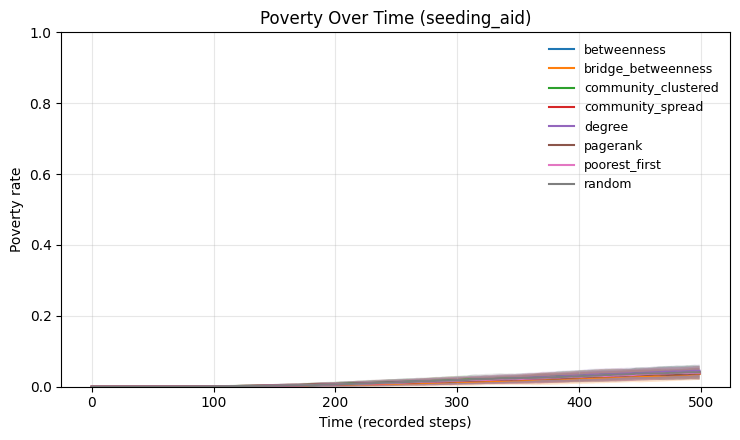

'../results/seeding_aid/fig_poverty_over_time_seeding_aid.png'

In [3]:
GROUP_COL = "graph_type" if EXPERIMENT == "topology_sweep" else "strategy"

fig = plt.figure(figsize=(7.5, 4.5))
ax = plt.gca()

for g in sorted(df_ts[GROUP_COL].unique()):
    sub = df_ts[df_ts[GROUP_COL] == g].sort_values("t")
    x = sub["t"].to_numpy()
    y = sub["pov_mean"].to_numpy()
    s = sub["pov_std"].to_numpy()

    ax.plot(x, y, label=str(g))
    ax.fill_between(x, y - s, y + s, alpha=0.2)

ax.set_xlabel("Time (recorded steps)")
ax.set_ylabel("Poverty rate")
ax.set_title(f"Poverty Over Time ({EXPERIMENT})")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, fontsize=9)

out = os.path.join(RESULTS_DIR, f"fig_poverty_over_time_{EXPERIMENT}.png")
fig.tight_layout()
fig.savefig(out, dpi=300)
plt.show()

out

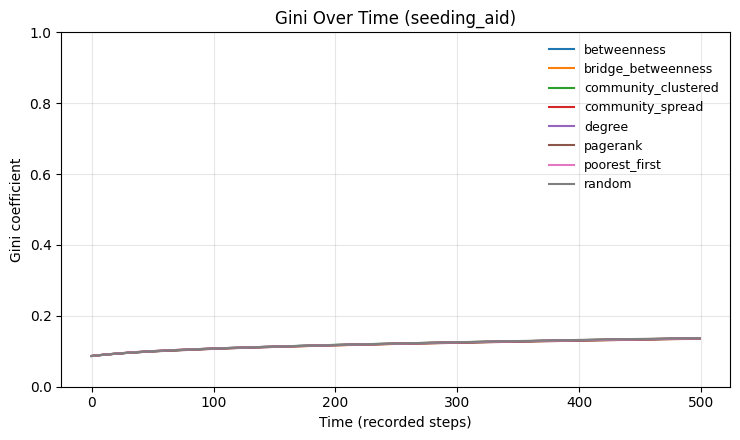

'../results/seeding_aid/fig_gini_over_time_seeding_aid.png'

In [4]:
fig = plt.figure(figsize=(7.5, 4.5))
ax = plt.gca()

for g in sorted(df_ts[GROUP_COL].unique()):
    sub = df_ts[df_ts[GROUP_COL] == g].sort_values("t")
    x = sub["t"].to_numpy()
    y = sub["gini_mean"].to_numpy()
    s = sub["gini_std"].to_numpy()

    ax.plot(x, y, label=str(g))
    ax.fill_between(x, y - s, y + s, alpha=0.2)

ax.set_xlabel("Time (recorded steps)")
ax.set_ylabel("Gini coefficient")
ax.set_title(f"Gini Over Time ({EXPERIMENT})")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, fontsize=9)

out = os.path.join(RESULTS_DIR, f"fig_gini_over_time_{EXPERIMENT}.png")
fig.tight_layout()
fig.savefig(out, dpi=300)
plt.show()

out

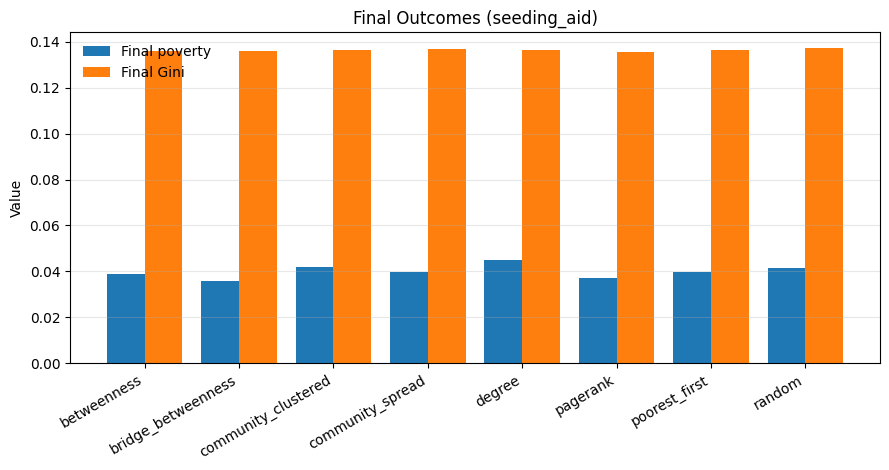

'../results/seeding_aid/fig_summary_final_seeding_aid.png'

In [5]:
GROUP_COL = "graph_type" if EXPERIMENT == "topology_sweep" else "strategy"

df_plot = df_sum.copy()
df_plot = df_plot.sort_values(GROUP_COL)

fig = plt.figure(figsize=(9, 4.8))
ax = plt.gca()

x = np.arange(len(df_plot))
w = 0.4

ax.bar(x - w/2, df_plot["poverty_final_mean"], w, label="Final poverty")
ax.bar(x + w/2, df_plot["gini_final_mean"], w, label="Final Gini")

ax.set_xticks(x)
ax.set_xticklabels(df_plot[GROUP_COL], rotation=30, ha="right")
ax.set_ylabel("Value")
ax.set_title(f"Final Outcomes ({EXPERIMENT})")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False)

out = os.path.join(RESULTS_DIR, f"fig_summary_final_{EXPERIMENT}.png")
fig.tight_layout()
fig.savefig(out, dpi=300)
plt.show()

out

In [6]:
# Keep only the most thesis-relevant columns
# cols = [
#     "graph_type", "params",
#     "escape_fraction_mean", "escape_time_mean",
#     "poverty_final_mean", "gini_final_mean",
#     "spearman_rank_corr_mean", "mean_abs_rank_change_mean"
# ]
# cols = [c for c in cols if c in df_sum.columns]
# df_display = df_sum[cols].copy()

# df_display[GROUP_COL] = df_display[GROUP_COL].map(lambda x: LABELS.get(x, x))
# df_display

cols = [GROUP_COL] + (["params"] if EXPERIMENT == "topology_sweep" and "params" in df_sum.columns else []) + [
    "poverty_final_mean", "gini_final_mean", "escape_fraction_mean", "escape_time_mean"
]
cols = [c for c in cols if c in df_sum.columns]

df_display = df_sum[cols].copy()
df_display[GROUP_COL] = df_display[GROUP_COL].map(lambda x: LABELS.get(x, str(x)))

df_display

,strategy,poverty_final_mean,gini_final_mean,escape_fraction_mean,escape_time_mean
0,betweenness,0.038955,0.136045,NaN,NaN
1,bridge_betweenness,0.035887,0.135986,NaN,NaN
2,community_clustered,0.041750,0.136430,NaN,NaN
3,community_spread,0.039672,0.136700,NaN,NaN
4,degree,0.045060,0.136271,NaN,NaN
5,pagerank,0.037248,0.135465,NaN,NaN
6,poorest_first,0.039548,0.136473,NaN,NaN
7,random,0.041369,0.137213,NaN,NaN
